In [17]:
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation
from gymnasium.wrappers import ResizeObservation
import ale_py
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from agent import Agent
from memories import *

In [18]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion() # interactive on

nbFrameStack = 4

In [ ]:
env = gym.make("ALE/Pong-v5", obs_type="grayscale")
print(env.observation_space.shape)
env = ResizeObservation(env, (84, 84)) 
print(env.observation_space.shape)
env = FrameStackObservation(env, stack_size=nbFrameStack)

(210, 160)
(84, 84)


## Hyperparameters for dueling, no Double learning

In [20]:
BATCH_SIZE = 32
GAMMA = 0.99
EPS_START = 1.0
EPS_END = 0.1
EPS_DECAY = 1000000
TAU = 0.005
LR = 1e-4
REPLAY_BUFFER_SIZE = 100000
trainingFrequency = 4
nbActions = env.action_space.n


# Hyperparameters for dueling, no Double learning and PER

In [21]:
BATCH_SIZE = 32
GAMMA = 0.99
EPS_START = 1.0
EPS_END = 0.1
EPS_DECAY = 100000
TAU = 0.005
LR = 6.25e-5
REPLAY_BUFFER_SIZE = 100000
trainingFrequency = 4
nbActions = env.action_space.n

In [22]:
def trainModel(num_episodes = 600, numGameAVG = 5, doubleMode = False, nStep = 1, weightName = "Model", usePer = False) :
  finalScore = []

  for game in range(numGameAVG) :
    finalGameScore = []
    
    agent = Agent(n_FrameStack=nbFrameStack, n_actions=nbActions, lr=LR, gamma=GAMMA, tau=TAU, device=device,
                   epsDecay=EPS_DECAY, epsEnd=EPS_END, epsStart=EPS_START,use_double_dqn=doubleMode, 
                   )
    memoryBuffer = ReplayMemory(REPLAY_BUFFER_SIZE, usePer=usePer)

    for i_episode in range(num_episodes):
      nStepMemory = SmallMemory(nStep, GAMMA)

      currentGameScore = 0

      if i_episode == 0:
        state, info = env.reset(seed=game)
      else :
        state, info = env.reset()
      #state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0) /255.0
      state = torch.tensor(state, dtype=torch.uint8).unsqueeze(0)

      for t in count():
          action = agent.select_action(state)
          observation, reward, terminated, truncated, _ = env.step(action)

          currentGameScore += reward

          #reward_tensor = torch.tensor([reward/100.0], dtype=torch.float32) ça marchait pour Qbert mais ça m'a saboté pour Pong
          reward_tensor = torch.tensor([reward], dtype=torch.float32)
          next_state = torch.tensor(observation, dtype=torch.uint8).unsqueeze(0) #/255
          done = terminated or truncated

          prevTrans = nStepMemory.push(state, action, next_state, reward_tensor, done)

          if prevTrans is not None :
            memoryBuffer.push(*prevTrans)
            
          # Move to the next state
          state = next_state

          if agent.numberStep % trainingFrequency == 0:
            deltas, indexs = agent.optimizeModel(memoryBuffer, batch_size=BATCH_SIZE, nStep=nStep)

            # Soft update of the target network's weights
            # θ′ ← τ θ + (1 −τ )θ′
            agent.softUpdateNetwork()

          if done :
              lastMoves = nStepMemory.flush()
              for transitions in lastMoves:
                  memoryBuffer.push(*transitions)

              finalGameScore.append(currentGameScore)
              break
      print(f"Episode n°{i_episode}")
      print(f"reward : {currentGameScore}")
      print(f"Number of steps : {t + 1}")
      print("=" *20)

    finalScore.append(finalGameScore)

  torch.save(agent.onlineNetwork.state_dict(), weightName)
  return finalScore

Episode n°0
reward : -19.0
Number of steps : 960
Episode n°1
reward : -21.0
Number of steps : 764
Episode n°2
reward : -21.0
Number of steps : 852
Episode n°3
reward : -19.0
Number of steps : 943
Episode n°4
reward : -21.0
Number of steps : 764
Episode n°5
reward : -21.0
Number of steps : 852
Episode n°6
reward : -21.0
Number of steps : 943
Episode n°7
reward : -21.0
Number of steps : 826
Episode n°8
reward : -20.0
Number of steps : 1072
Episode n°9
reward : -20.0
Number of steps : 1051
Episode n°10
reward : -19.0
Number of steps : 1158
Episode n°11
reward : -21.0
Number of steps : 872
Episode n°12
reward : -21.0
Number of steps : 845
Episode n°13
reward : -20.0
Number of steps : 951
Episode n°14
reward : -21.0
Number of steps : 1032
Episode n°15
reward : -20.0
Number of steps : 975
Episode n°16
reward : -21.0
Number of steps : 1006
Episode n°17
reward : -21.0
Number of steps : 1001
Episode n°18
reward : -21.0
Number of steps : 792
Episode n°19
reward : -20.0
Number of steps : 926
Epis

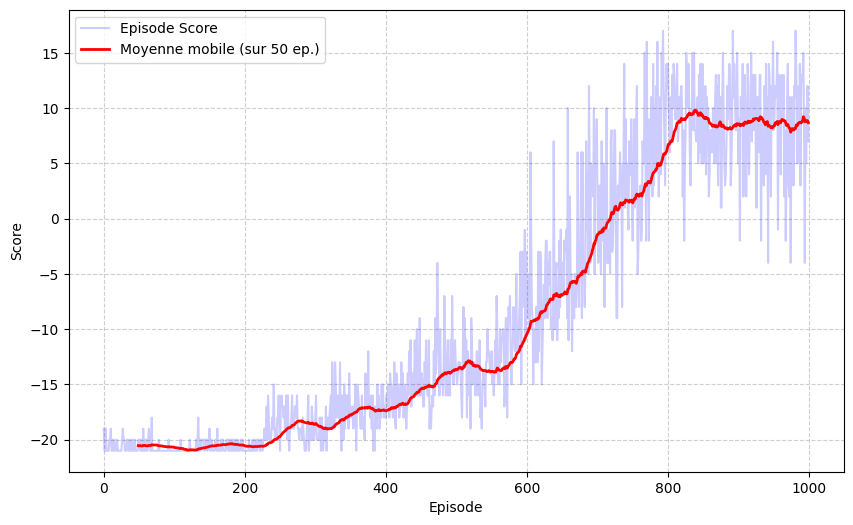

In [23]:
finalScore = trainModel(1000, 1, doubleMode=False, nStep=3, weightName="PERDuelingPong3-Step.pth", usePer=True)

scores_bruts = finalScore[0] 

df_scores = pd.DataFrame({
    "Episode": range(len(scores_bruts)),
    "Reward": scores_bruts
})

nom_fichier_csv = "scores_PER_DuelingPong3-Step.csv"
df_scores.to_csv(nom_fichier_csv, index=False)


fenetre = 50
scores_lisses = pd.Series(scores_bruts).rolling(window=fenetre).mean()

plt.figure(figsize=(10, 6)) 


plt.plot(scores_bruts, alpha=0.2, color='blue', label='Episode Score')

plt.plot(scores_lisses, color='red', linewidth=2, label=f'Moving avergae (on {fenetre} ep.)')

plt.xlabel("Episode")
plt.ylabel("Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [24]:
pong_files = [
    "scores_DoublePong3-Step.csv",
    "scores_DuelingPong1-Step.csv",
    "scores_DuelingPong3-Step.csv",
    "scores_PER_DuelingPong3-Step.csv"
]

qbert_files = [
    "scoreQbertN3DoubleNoPrio.csv",
    "scores_DoubleQbert1-Step.csv",
    "scores_DoubleQbert3-Step.csv",
    "scores_DuelingQbert3-Step.csv"
]

def plot_progression(file_list, game_name, window=20):
    plt.figure(figsize=(12, 6))
    
    for file in file_list:
        
        df = pd.read_csv(file)
        df.columns = [c.capitalize() for c in df.columns]

        df = df.sort_values('Episode')
        
        smoothed = df['Reward'].rolling(window=window, min_periods=1).mean()
        
        label = file.replace('scores_', '').replace('.csv', '')
        line, = plt.plot(df['Episode'], smoothed, label=label, linewidth=2)
        plt.plot(df['Episode'], df['Reward'], alpha=0.15, color=line.get_color())
        

    plt.title(f"Score's evolution by episode - {game_name} (moving average {window} episodes)")
    plt.xlabel("Episodes")
    plt.ylabel("Score (Reward)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()


plot_progression(pong_files, "Pong", "pong_scores.png")
plot_progression(qbert_files, "Qbert", "qbert_scores.png")

ValueError: window must be an integer 0 or greater

<Figure size 1200x600 with 0 Axes>